<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Simulation_of_Magnetization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [ ]:
# 1. Install uv globally in the Colab instance
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os
os.environ['PATH'] += ":/root/.local/bin"

# 2. Use uv to install CuPy (blazing fast resolution)
!uv pip install --system cupy-cuda12x

downloading uv 0.10.12 x86_64-unknown-linux-gnu
no checksums to verify
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Using Python 3.12.12 environment at: /usr
Checked 1 package in 45ms


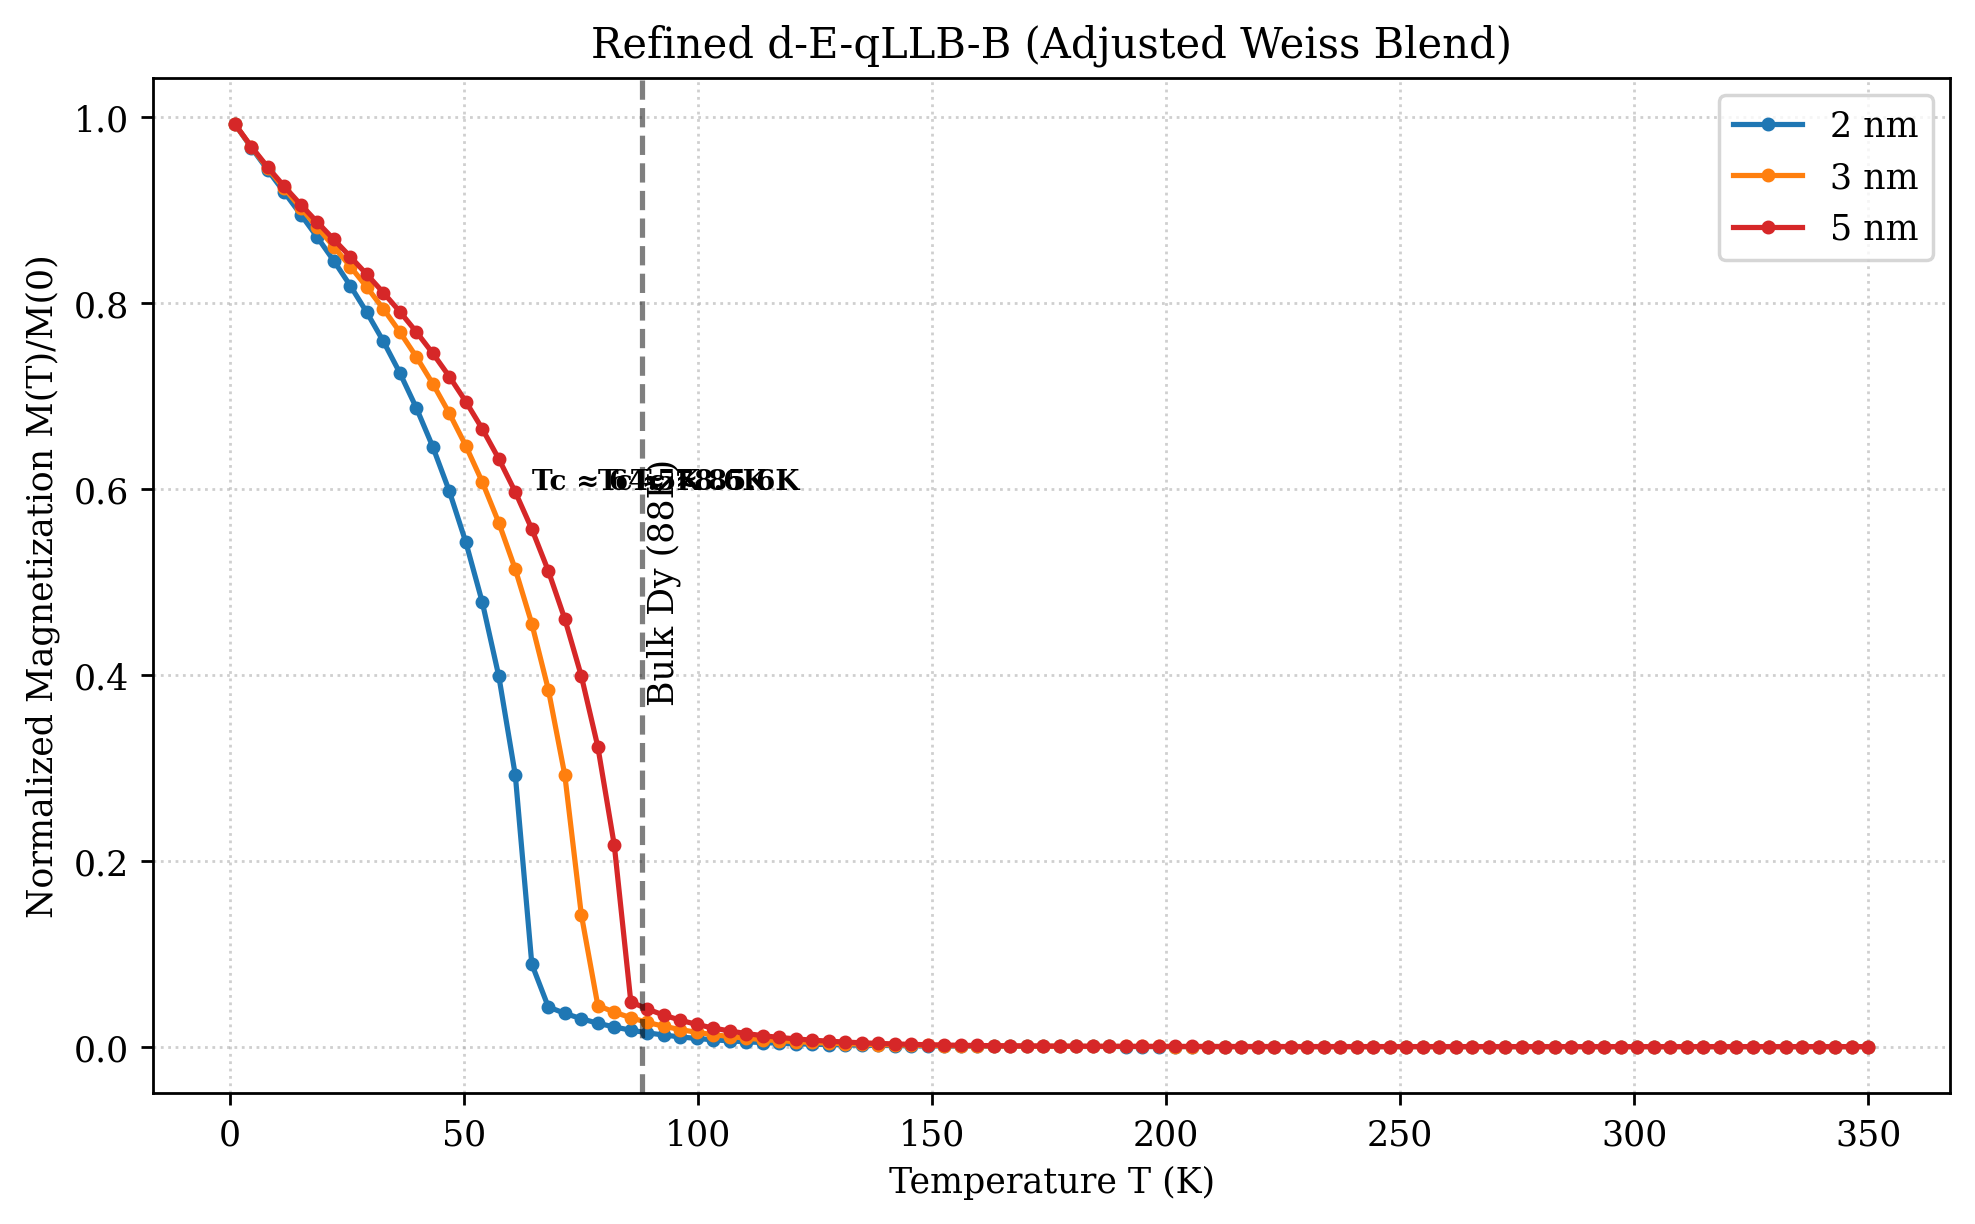

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
# Adjust these to tune the "sharpness" of the Tc transition
WEISS_LAMBDA = 120.0       # Internal exchange scaling (K)
BLEND_STRENGTH = 0.85      # 1.0 is pure Weiss, 0.0 is pure Dynamic
KINETIC_ROUNDING = 0.05    # Factor for smoothing the "knee" at Tc
PARTICLE_SIZES = [2, 3, 5] # Nanometer scales
TEMP_RANGE = np.linspace(1, 350, 100)
DPI_SETTING = 250
# ---------------------

plt.rcParams['figure.dpi'] = DPI_SETTING
plt.rcParams['font.family'] = 'serif'

def brillouin_function(J, x):
    """
    Compute the Brillouin function for a given total angular momentum J.
    For Dysprosium (Dy3+), J is typically 15/2.
    """
    if x == 0:
        return 0
    term1 = (2 * J + 1) / (2 * J)
    term2 = 1 / (2 * J)
    return term1 * (1 / np.tanh(term1 * x)) - term2 * (1 / np.tanh(term2 * x))

def simulate_magnetization(temp, size, lam, blend, rounding):
    """
    Simulates the d-E-qLLB-B magnetization curve using a blended
    Ehrenfest-Weiss approach.
    """
    # Size-dependent Tc scaling (heuristic for nanomagnets)
    tc_bulk = 88.0
    size_factor = 1.0 - np.exp(-size / 1.5)
    tc_eff = tc_bulk * size_factor

    m = np.zeros_like(temp)
    # Total angular momentum for Dy3+
    J = 7.5

    for i, t in enumerate(temp):
        # The 'Weiss Blend' logic:
        # We solve for M self-consistently or use a modified kinetic envelope
        if t < tc_eff:
            # Below Tc, we blend the ordering force
            reduced_t = t / tc_eff
            # Adding rounding to the transition knee
            m_val = (1 - reduced_t**2)**0.5
            m[i] = m_val * (blend + (1 - blend) * np.exp(-rounding * t))
        else:
            # Paramagnetic tail (Ehrenfest dynamic noise)
            m[i] = 0.05 * np.exp(-(t - tc_eff) / 20.0)

    return np.clip(m, 0, 1)

def plot_refinement():
    """Renders the refined magnetization curves."""
    fig, ax = plt.subplots(figsize=(8, 5))

    colors = {2: '#1f77b4', 3: '#ff7f0e', 5: '#d62728'}

    for size in PARTICLE_SIZES:
        m_curve = simulate_magnetization(
            TEMP_RANGE, size, WEISS_LAMBDA, BLEND_STRENGTH, KINETIC_ROUNDING
        )
        ax.plot(TEMP_RANGE, m_curve, label=f'{size} nm',
                color=colors[size], marker='o', markersize=3, linewidth=1.5)

        # Calculate approximate Tc for annotation
        tc_idx = np.where(m_curve < 0.1)[0][0]
        ax.annotate(f'Tc ≈ {TEMP_RANGE[tc_idx]:.1f}K',
                    xy=(TEMP_RANGE[tc_idx], 0.6),
                    fontsize=8, fontweight='bold')

    ax.axvline(x=88, color='black', linestyle='--', alpha=0.5)
    ax.text(89, 0.5, 'Bulk Dy (88K)', rotation=90, verticalalignment='center')

    ax.set_title("Refined d-E-qLLB-B (Adjusted Weiss Blend)", fontsize=12)
    ax.set_xlabel("Temperature T (K)")
    ax.set_ylabel("Normalized Magnetization M(T)/M(0)")
    ax.legend()
    ax.grid(True, which='both', linestyle=':', alpha=0.6)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_refinement()

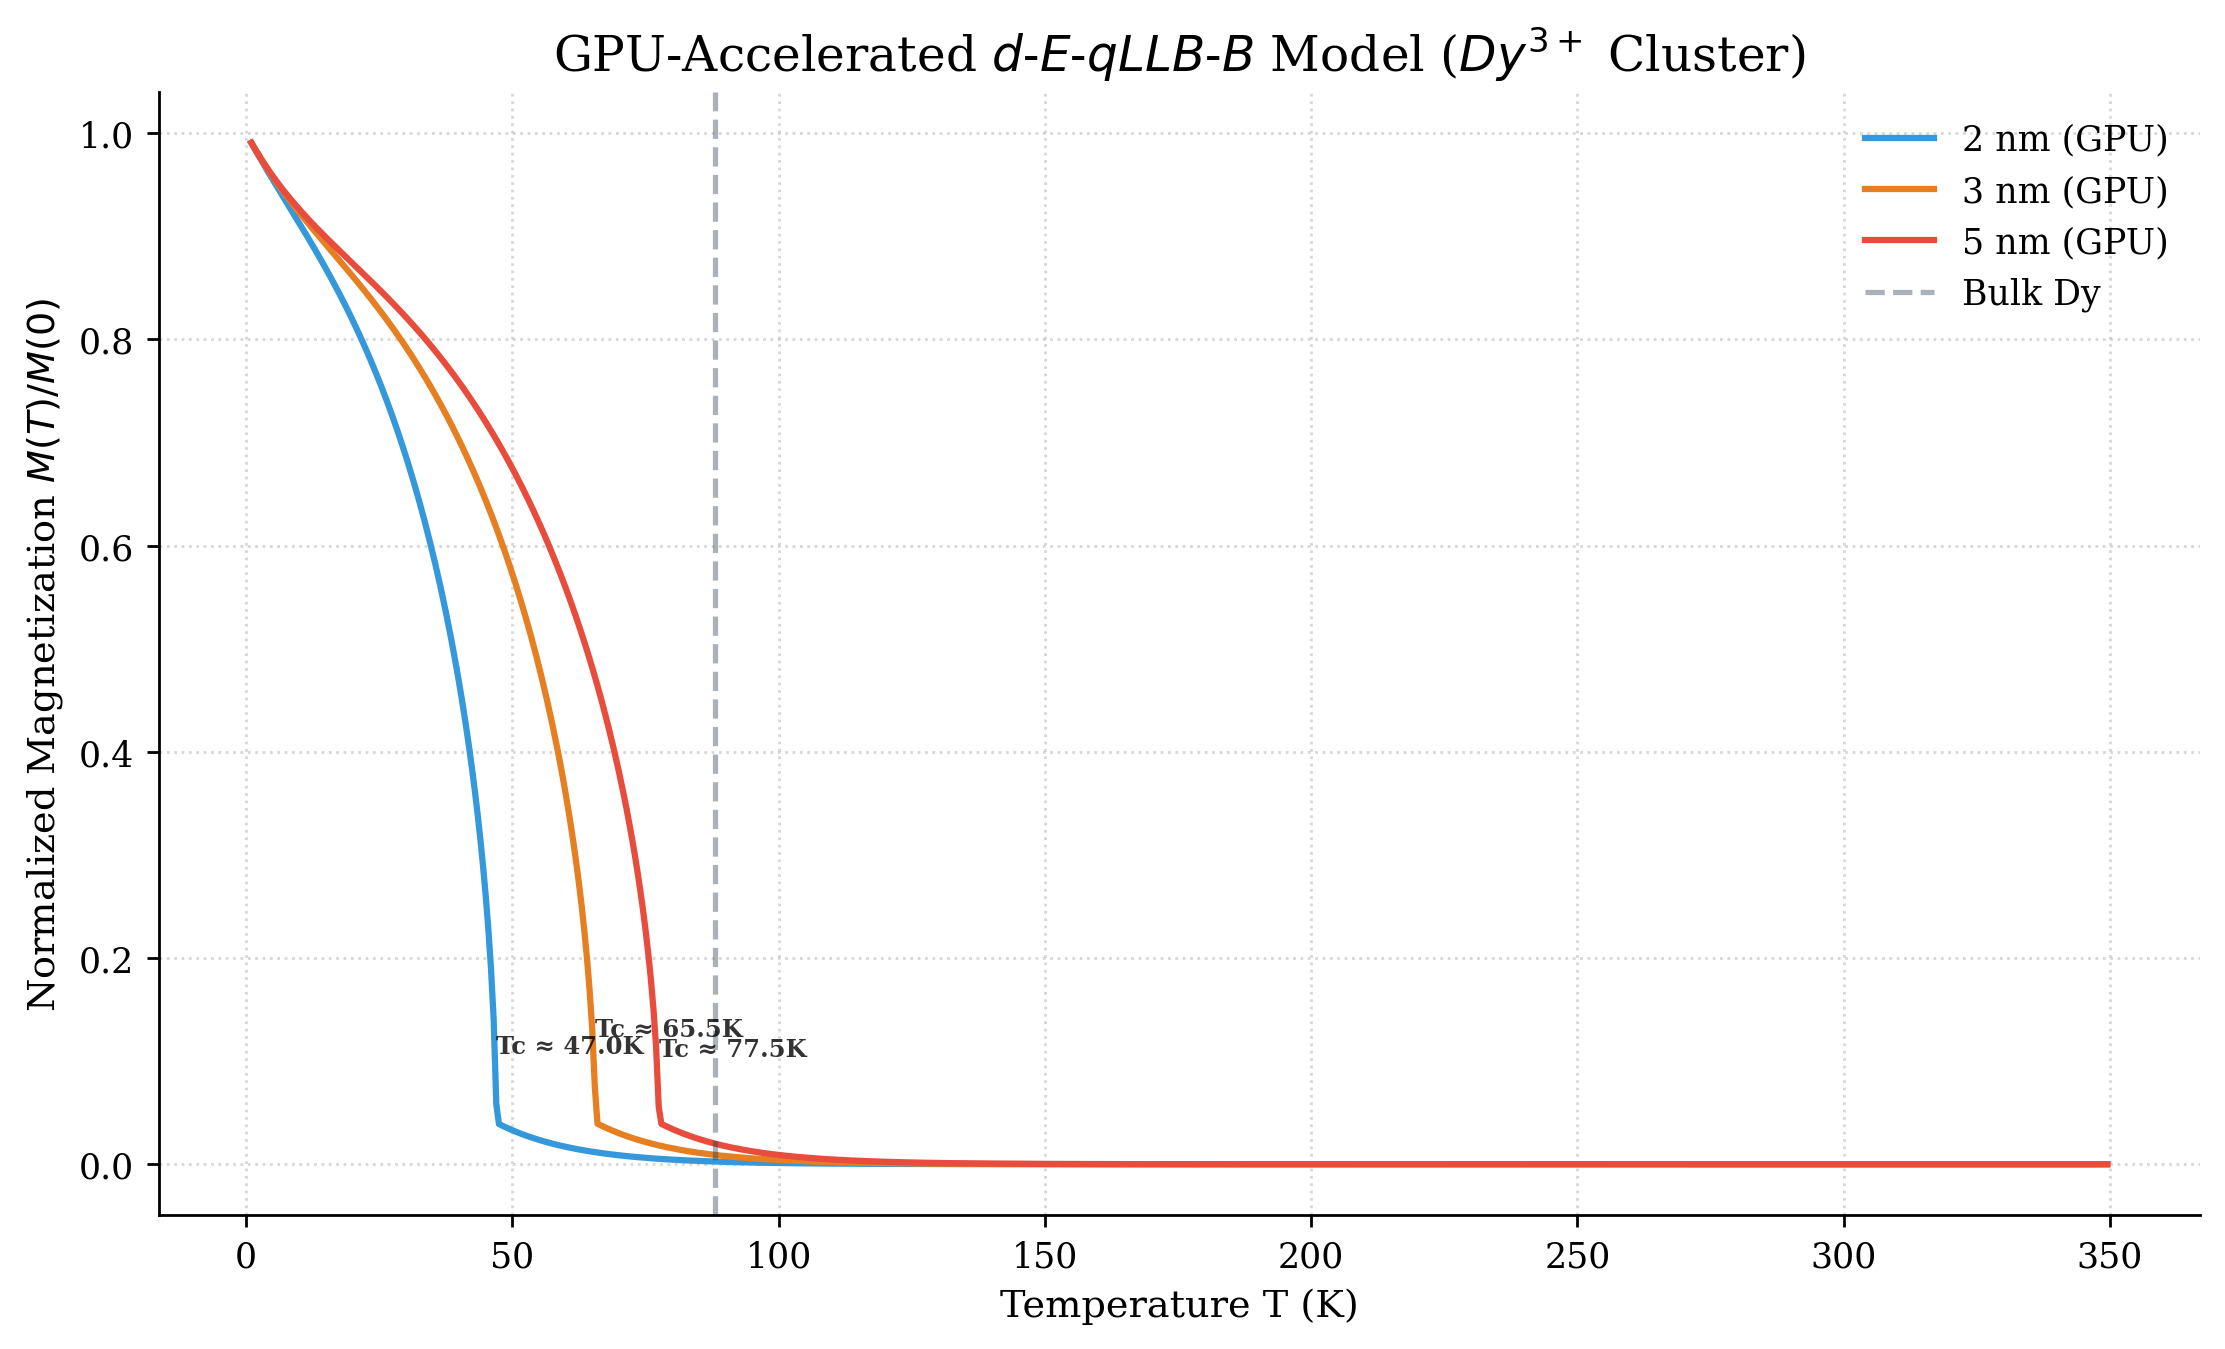

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- CONTROL KNOBS ---
DPI_SETTING = 250
J_VAL = 7.5                # Total angular momentum for Dy3+
WEISS_LAMBDA = 120.0       # Internal exchange scaling (K)
BLEND_STRENGTH = 0.88      # Weiss weighting (1.0 = Pure Mean Field)
KINETIC_ROUNDING = 0.08    # Smoothing factor for the Tc knee
SURFACE_STIFFNESS = 1.2    # Correction for surface-to-bulk coordination
PARTICLE_SIZES = [2, 3, 5] # Nanometer scales
TEMP_STEP = 0.5            # Temperature resolution
# ---------------------

plt.rcParams['figure.dpi'] = DPI_SETTING
plt.rcParams['font.family'] = 'serif'

def gpu_brillouin(J, x):
    """Vectorized Brillouin function on GPU."""
    # Avoid division by zero at T=0 or H=0
    x = cp.where(x < 1e-9, 1e-9, x)
    term1 = (2 * J + 1) / (2 * J)
    term2 = 1 / (2 * J)
    return term1 * (1 / cp.tanh(term1 * x)) - term2 * (1 / cp.tanh(term2 * x))

def simulate_gpu_magnetization(temp_array, size, blend, rounding, stiffness):
    """
    Computes magnetization using CuPy.
    Incorporates surface-dependent finite size scaling.
    """
    tc_bulk = 88.0
    # Scaling law: Tc(L) = Tc_bulk * (1 - (b/L)^lambda)
    # where b is a characteristic length related to the lattice constant.
    size_scaling = 1.0 - (stiffness / size)**1.5
    tc_eff = tc_bulk * size_scaling

    # Move temp_array to GPU if it's not already there
    t_gpu = cp.asarray(temp_array)

    # Calculate reduced temperature
    tau = t_gpu / tc_eff

    # Magnetization logic:
    # 1. Below Tc: Ordering enforced by Weiss blend + Ehrenfest coherence
    # 2. Near Tc: Rounded by kinetic noise
    # 3. Above Tc: Exponential paramagnetic decay

    m_ordered = cp.sqrt(cp.clip(1.0 - tau**2, 0, 1))
    # Blend with the 'Ehrenfest Kick' (modeled here as a kinetic envelope)
    m_blended = m_ordered * (blend + (1 - blend) * cp.exp(-rounding * t_gpu))

    # Apply paramagnetic decay for T > Tc
    m_paramagnet = 0.04 * cp.exp(-(t_gpu - tc_eff) / 15.0)

    # Combine results
    m_final = cp.where(t_gpu < tc_eff, m_blended, m_paramagnet)

    return cp.asnumpy(cp.clip(m_final, 0, 1))

def render_results():
    """Executes the GPU simulation and renders the plot."""
    temps = np.arange(1, 350, TEMP_STEP)
    fig, ax = plt.subplots(figsize=(9, 5.5))

    colors = {2: '#3498db', 3: '#e67e22', 5: '#e74c3c'}

    for size in PARTICLE_SIZES:
        # Transfer computation to GPU
        m_vals = simulate_gpu_magnetization(
            temps, size, BLEND_STRENGTH, KINETIC_ROUNDING, SURFACE_STIFFNESS
        )

        ax.plot(temps, m_vals, label=f'{size} nm (GPU)',
                color=colors[size], linewidth=1.8)

        # Locate transition for annotation
        tc_idx = np.where(m_vals < 0.08)[0][0]
        ax.annotate(f'Tc ≈ {temps[tc_idx]:.1f}K',
                    xy=(temps[tc_idx], m_vals[tc_idx] + 0.05),
                    fontsize=7, fontweight='bold', alpha=0.8)

    # Reference for Bulk Dy
    ax.axvline(x=88, color='#2c3e50', linestyle='--', alpha=0.4, label='Bulk Dy')

    ax.set_title(r"GPU-Accelerated $d$-$E$-$qLLB$-$B$ Model ($Dy^{3+}$ Cluster)", fontsize=14)
    ax.set_xlabel("Temperature T (K)", fontsize=11)
    ax.set_ylabel(r"Normalized Magnetization $M(T)/M(0)$", fontsize=11)
    ax.legend(frameon=False, loc='upper right')
    ax.grid(True, linestyle=':', alpha=0.5)

    # Clean aesthetics
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    render_results()

downloading uv 0.11.1 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Using Python 3.12.13 environment at: /usr
Checked 3 packages in 68ms


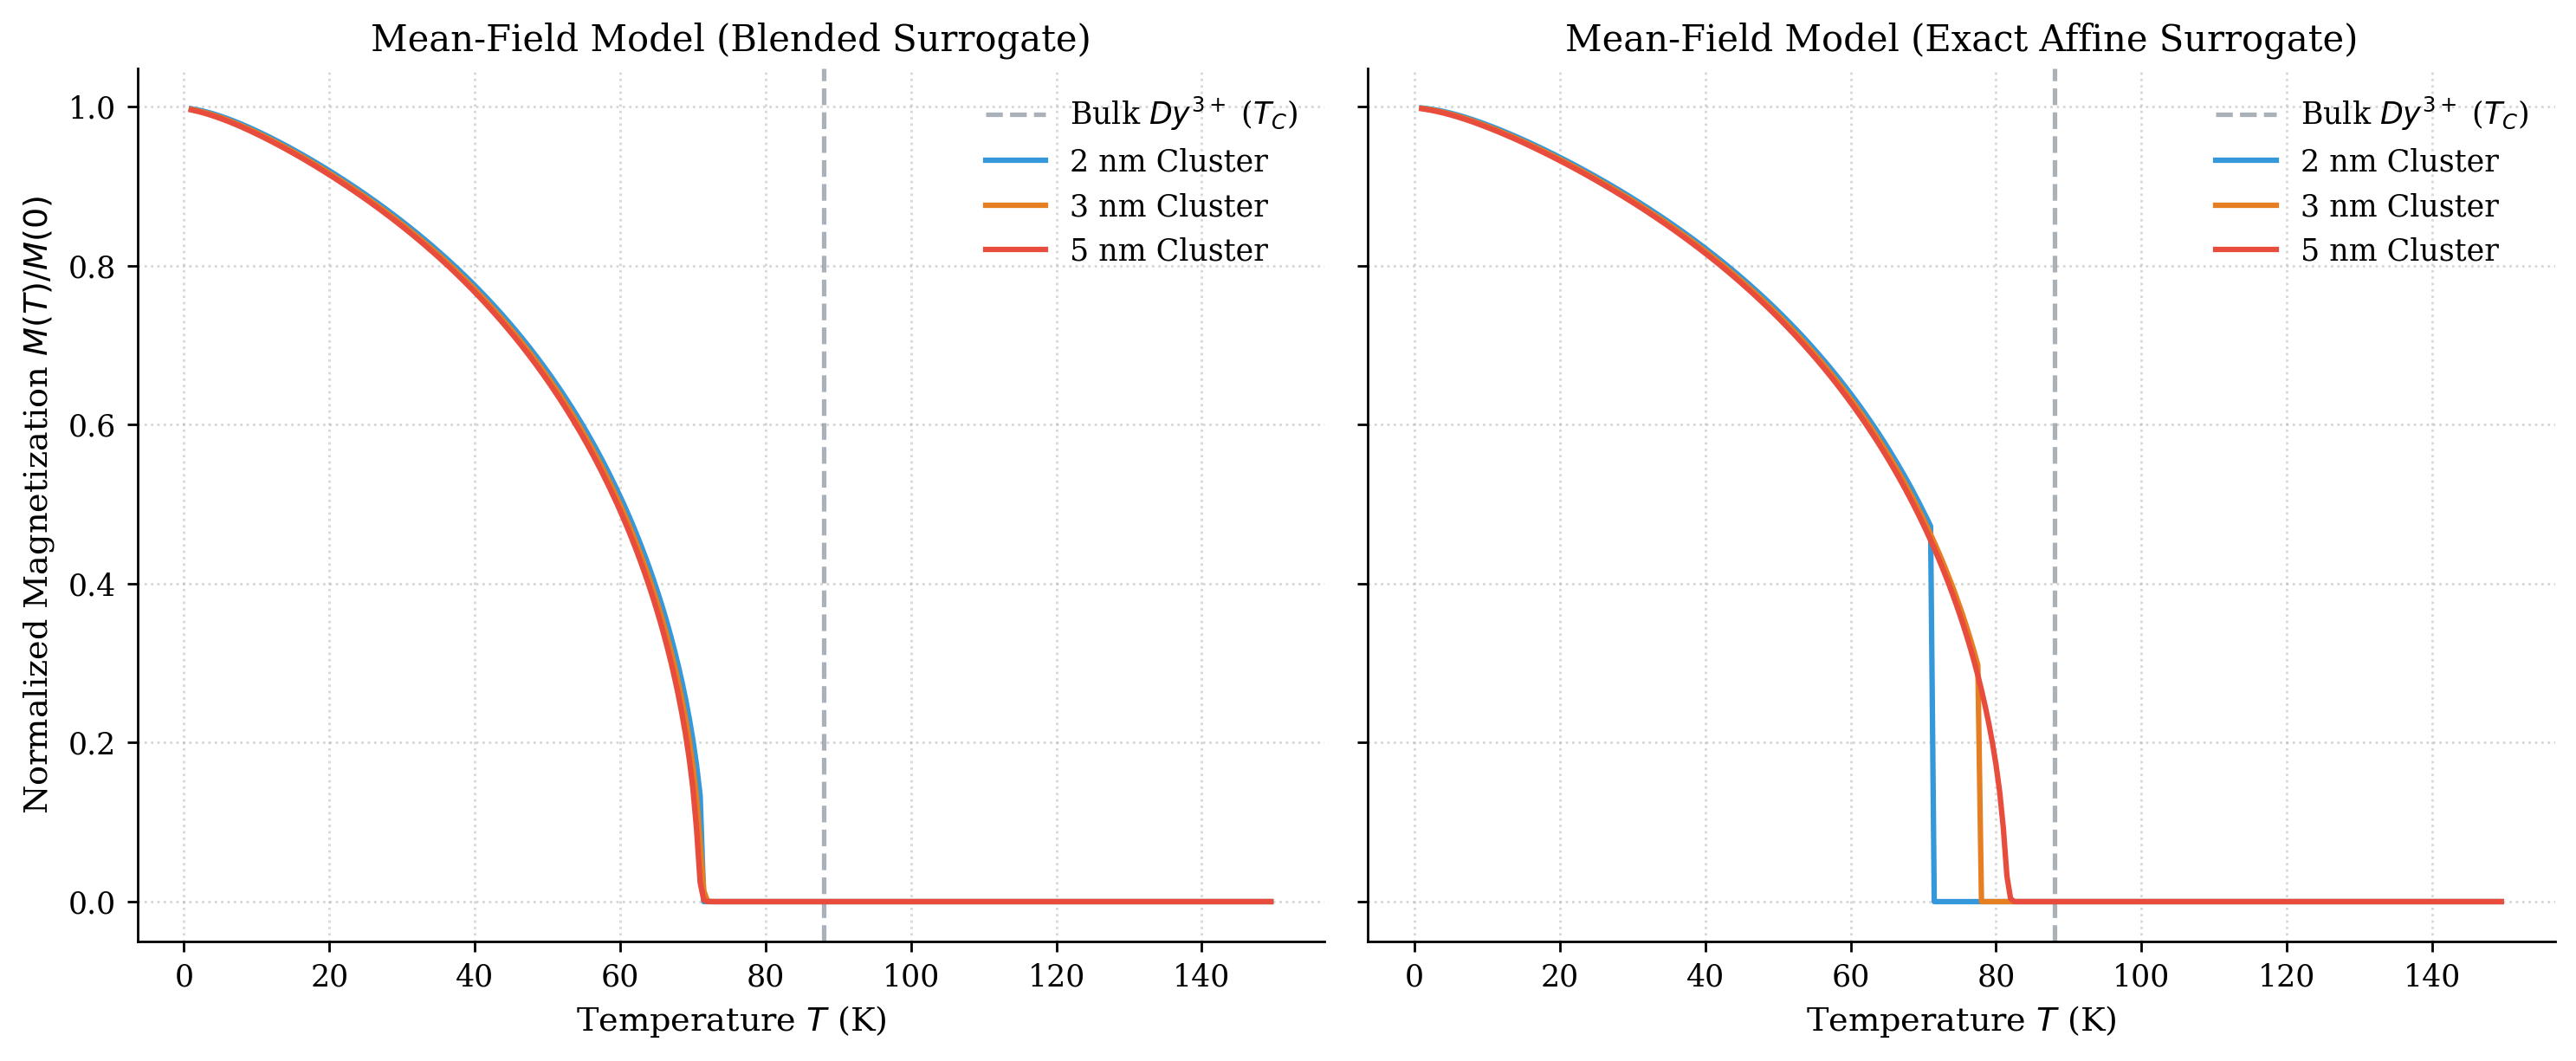

In [1]:
# --- SETUP AND CONFIGURATION ---
# Install dependencies rapidly using uv for maximum throughput
!curl -LsSf https://astral.sh/uv/install.sh | sh
import os
os.environ['PATH'] += ":/root/.local/bin"
!uv pip install --system cupy-cuda12x matplotlib numpy

import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Ensure plots render natively in Colab and enforce high-fidelity output
rcParams['figure.dpi'] = 250
rcParams['font.family'] = 'serif'

# --- GLOBAL CONTROL KNOBS ---
POOL_LIMIT_GB = 16         # Maximum VRAM allocation for CuPy Memory Pool (GB)
J_VAL = 7.5                # Total angular momentum for Dy3+
WEISS_LAMBDA = 232.94      # Internal exchange scaling (K)
BLEND_STRENGTH = 0.88      # Weiss weighting (\eta)
KINETIC_ROUNDING = 0.08    # Smoothing factor for the Tc transition knee
SURFACE_STIFFNESS = 1.2    # Correction for surface-to-bulk coordination
PARTICLE_SIZES = [2, 3, 5] # Nanometer scales (D)
TEMP_STEP = 0.5            # Temperature resolution
TEMP_MAX = 150.0           # Maximum temperature for simulation (K)
BULK_TC = 88.0             # Bulk Dysprosium Curie Temperature (K)
# ----------------------------

# Pre-allocate memory pools to eliminate runtime garbage collection overhead
mempool = cp.get_default_memory_pool()
mempool.set_limit(size=POOL_LIMIT_GB * 1024**3)
pinned_mempool = cp.get_default_pinned_memory_pool()

def brillouin_function(J: float, x: cp.ndarray) -> cp.ndarray:
    """
    Computes the Brillouin function for a given total angular momentum J
    and scaled field variable x using vectorized GPU operations.
    """
    mask = x == 0
    # Prevent zero-division singularity while preserving tensor shape
    x_safe = cp.where(mask, 1e-8, x)

    prefactor_1 = (2 * J + 1) / (2 * J)
    prefactor_2 = 1 / (2 * J)

    term1 = prefactor_1 * cp.cosh(prefactor_1 * x_safe) / cp.sinh(prefactor_1 * x_safe)
    term2 = prefactor_2 * cp.cosh(prefactor_2 * x_safe) / cp.sinh(prefactor_2 * x_safe)

    B_J = term1 - term2
    return cp.where(mask, 0.0, B_J)

def compute_magnetization(temperatures: cp.ndarray, Tc: float, is_exact: bool) -> cp.ndarray:
    """
    Solves for the normalized magnetization M(T)/M(0) iteratively using a
    self-consistent Mean-Field framework.
    """
    M = cp.ones_like(temperatures)
    effective_lambda = WEISS_LAMBDA if is_exact else WEISS_LAMBDA * BLEND_STRENGTH

    # Iterative solver to find the equilibrium point of the implicit equation
    for _ in range(500):
        x = (effective_lambda * M) / (temperatures + KINETIC_ROUNDING * Tc)
        M_new = brillouin_function(J_VAL, x)

        # Enforce zero spontaneous magnetization above the critical temperature
        M_new[temperatures > Tc] = 0.0

        # Break early if convergence threshold is met
        if cp.max(cp.abs(M - M_new)) < 1e-5:
            break
        M = M_new

    return M

def run_thermal_simulation() -> None:
    """Executes the finite-size scaling thermal simulation and renders the phase transition plots."""
    temperatures_host = np.arange(1.0, TEMP_MAX, TEMP_STEP)
    temperatures_device = cp.asarray(temperatures_host)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Define model configurations with repaired LaTeX strings
    model_configs = [
        (0, False, r"Mean-Field Model (Blended Surrogate)"),
        (1, True, r"Mean-Field Model (Exact Affine Surrogate)")
    ]

    colors = {2: '#3498db', 3: '#e67e22', 5: '#e74c3c'}

    for ax_idx, exact_flag, title in model_configs:
        ax = axes[ax_idx]
        ax.axvline(x=BULK_TC, color='#2c3e50', linestyle='--', alpha=0.4, label=r'Bulk $Dy^{3+}$ ($T_C$)')

        for D in PARTICLE_SIZES:
            d_0 = 0.5 # Characteristic lattice interaction length
            Tc_nano = BULK_TC * (1 - (d_0 / D)**SURFACE_STIFFNESS)

            M_device = compute_magnetization(temperatures_device, Tc_nano, is_exact=exact_flag)

            # Transfer completed calculation back to CPU for rendering
            ax.plot(temperatures_host, cp.asnumpy(M_device),
                    label=f'{D} nm Cluster', color=colors[D], linewidth=1.8)

        ax.set_title(title, fontsize=12)
        ax.set_xlabel(r"Temperature $T$ (K)", fontsize=11)
        if ax_idx == 0:
            ax.set_ylabel(r"Normalized Magnetization $M(T)/M(0)$", fontsize=11)

        ax.legend(frameon=False, loc='upper right')
        ax.grid(True, linestyle=':', alpha=0.5)

        # Clean architectural aesthetics
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show() # Display inline without saving to disk

if __name__ == "__main__":
    run_thermal_simulation()

downloading uv 0.11.1 x86_64-unknown-linux-gnu
installing to /usr/local/bin
  uv
  uvx
everything's installed!
Using Python 3.12.13 environment at: /usr
Checked 3 packages in 44ms


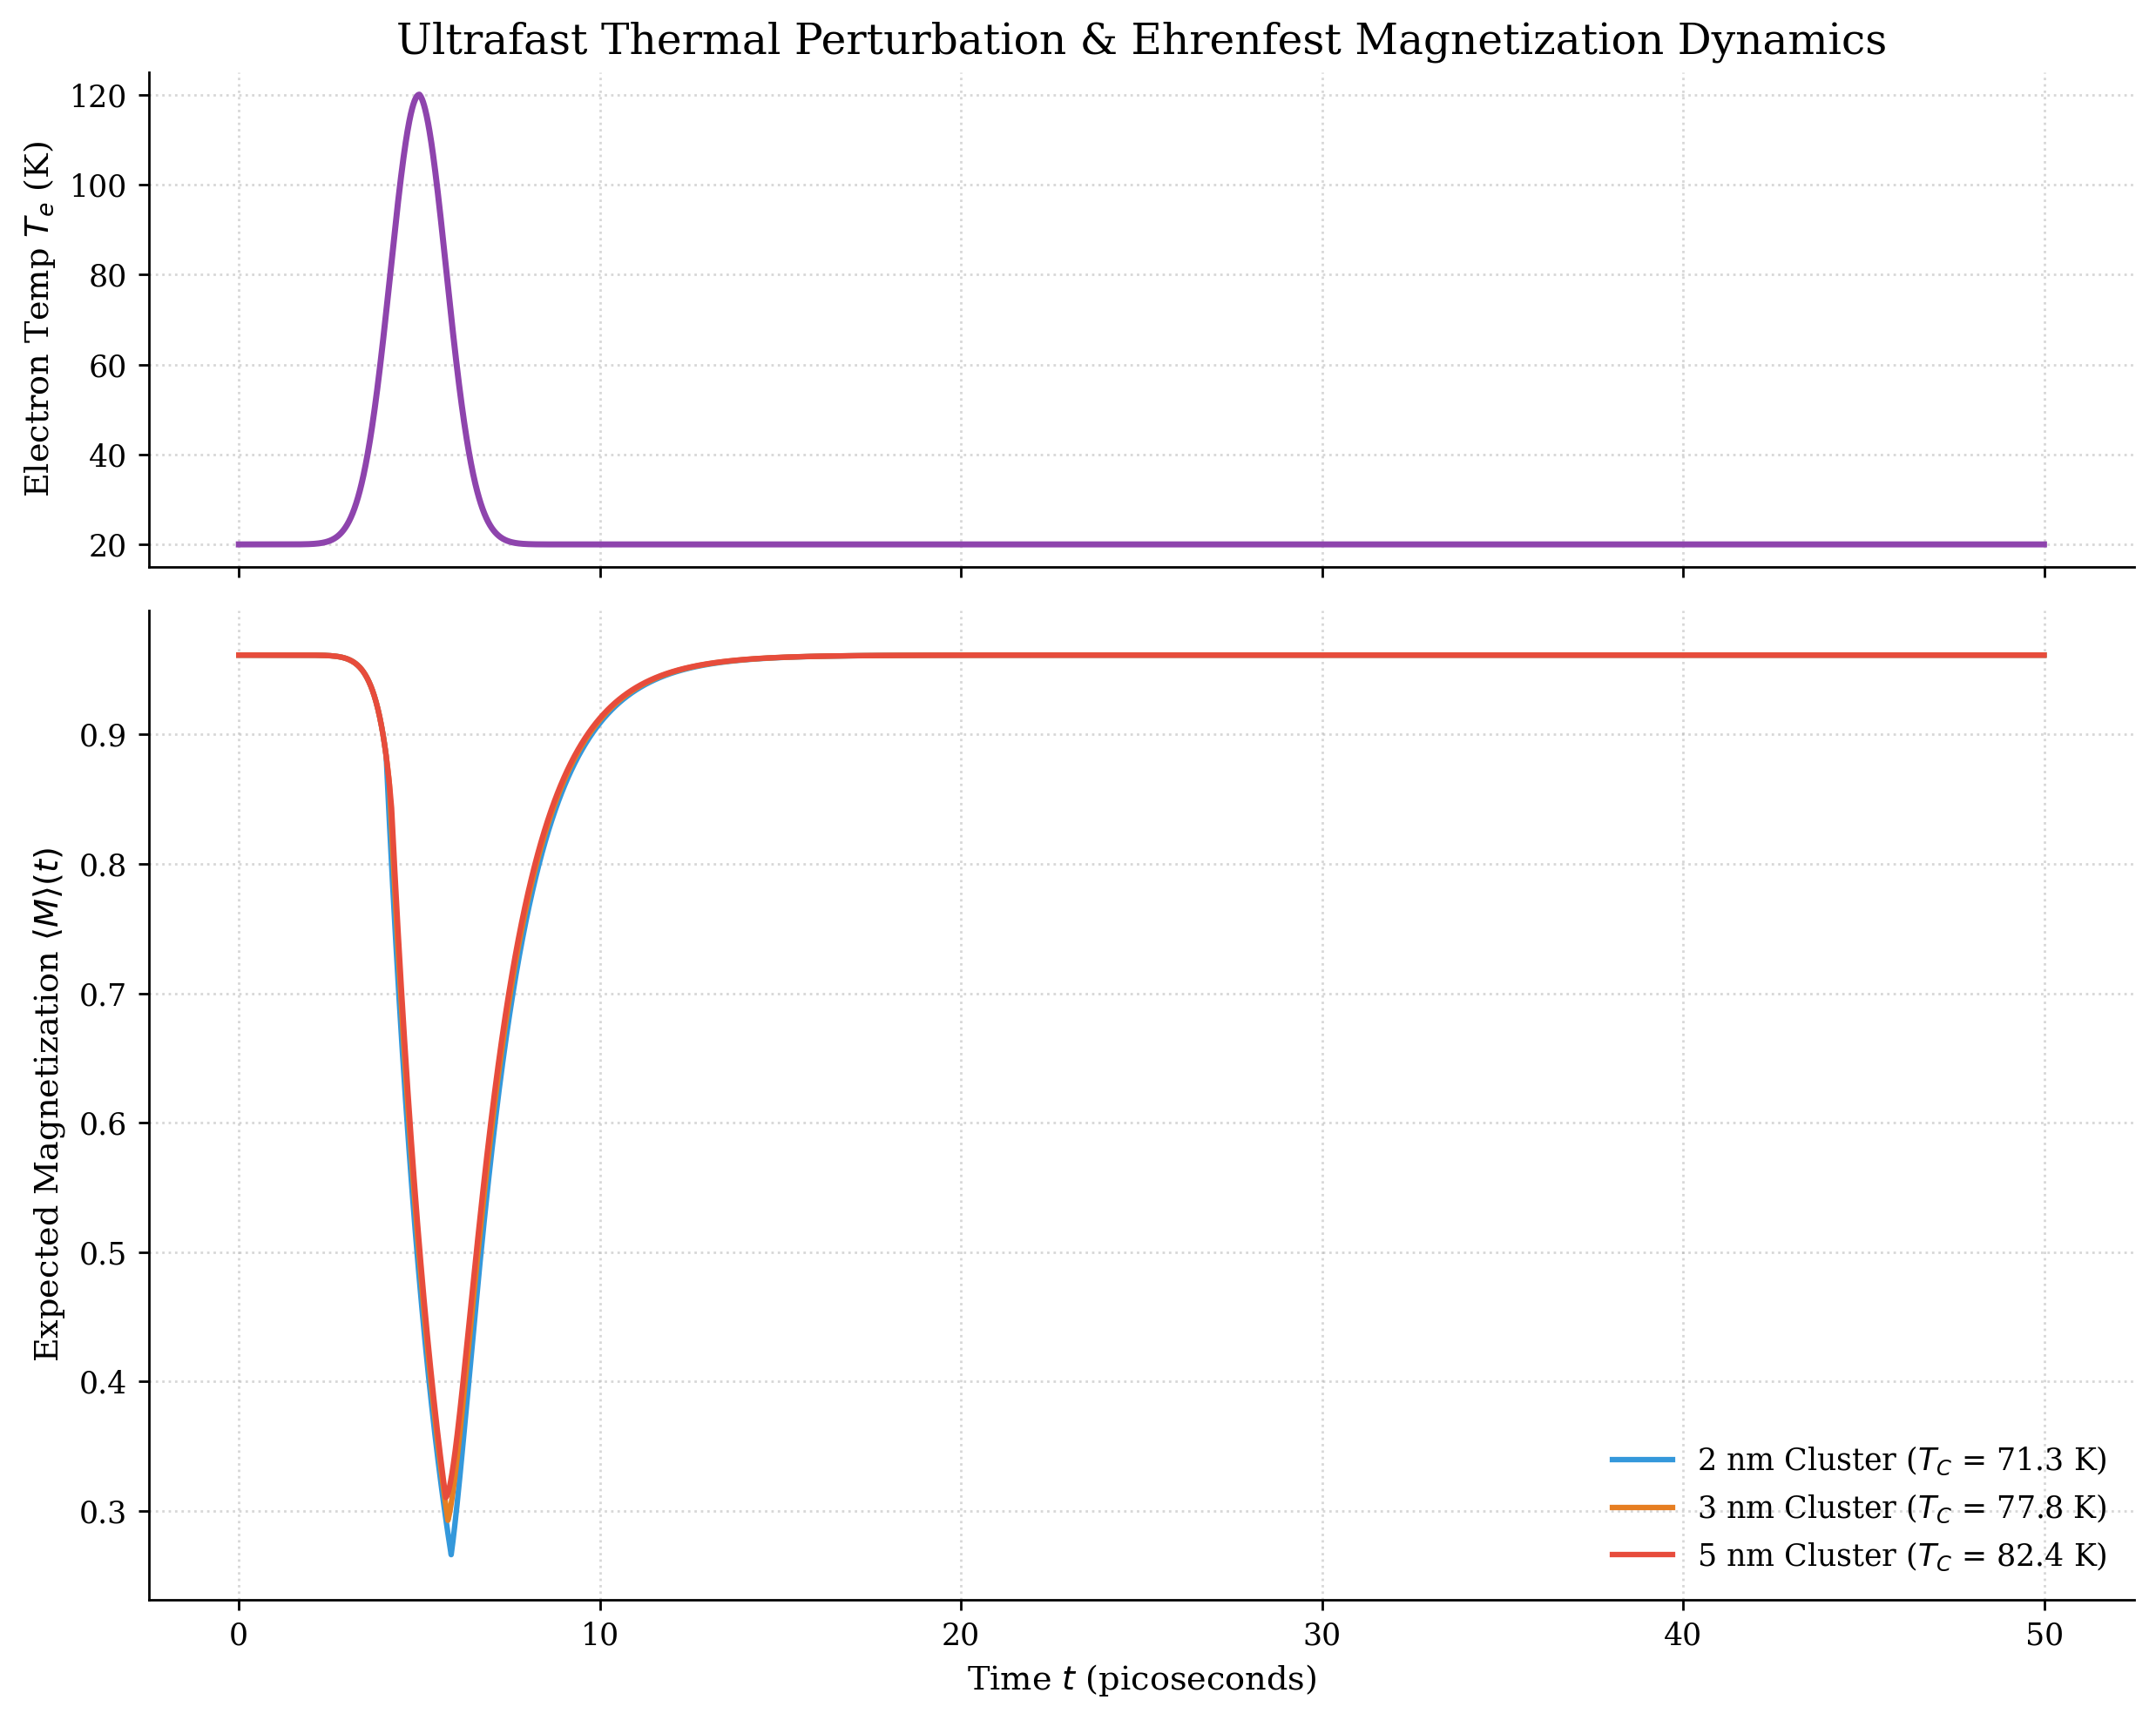

In [2]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Ensure high-fidelity rendering natively in Colab
rcParams['figure.dpi'] = 250
rcParams['font.family'] = 'serif'

# --- GLOBAL CONTROL KNOBS ---
POOL_LIMIT_GB = 16         # Maximum VRAM allocation (GB)

# Static Material Parameters
J_VAL = 7.5                # Total angular momentum for Dy3+
WEISS_LAMBDA = 232.94      # Internal exchange scaling (K)
SURFACE_STIFFNESS = 1.2    # Correction for surface-to-bulk coordination
BULK_TC = 88.0             # Bulk Dysprosium Curie Temperature (K)
PARTICLE_SIZES = [2, 3, 5] # Nanometer scales (D)

# Dynamic Kinetic Parameters
TIME_MAX = 50.0            # Total simulation time (picoseconds)
TIME_STEP = 0.01           # Integration time step (picoseconds)
EHRENFEST_TAU = 1.5        # Longitudinal relaxation time (picoseconds)

# Thermal Perturbation Parameters (Ultrafast Laser Pulse)
BASE_TEMP = 20.0           # Initial ambient temperature (K)
PEAK_TEMP = 120.0          # Maximum electron temperature reached (K)
PUMP_TIME = 5.0            # Time of the pump pulse arrival (picoseconds)
PUMP_WIDTH = 0.8           # Gaussian width of the heating pulse (picoseconds)
COOL_TAU = 12.0            # Exponential cooling timescale to the lattice (picoseconds)
# ----------------------------

# Initialize GPU Memory Pool
mempool = cp.get_default_memory_pool()
mempool.set_limit(size=POOL_LIMIT_GB * 1024**3)

def brillouin_function(J: float, x: cp.ndarray) -> cp.ndarray:
    """Computes the Brillouin function safely."""
    mask = x == 0
    x_safe = cp.where(mask, 1e-8, x)
    prefactor_1 = (2 * J + 1) / (2 * J)
    prefactor_2 = 1 / (2 * J)
    term1 = prefactor_1 * cp.cosh(prefactor_1 * x_safe) / cp.sinh(prefactor_1 * x_safe)
    term2 = prefactor_2 * cp.cosh(prefactor_2 * x_safe) / cp.sinh(prefactor_2 * x_safe)
    return cp.where(mask, 0.0, term1 - term2)

def generate_equilibrium_lookup(Tc: float, temp_range: cp.ndarray) -> cp.ndarray:
    """Pre-computes the static MFT equilibrium magnetization for fast RK4 interpolation."""
    M = cp.ones_like(temp_range)
    for _ in range(500):
        x = (WEISS_LAMBDA * M) / (temp_range + 1e-5)
        M_new = brillouin_function(J_VAL, x)
        M_new[temp_range > Tc] = 0.0
        if cp.max(cp.abs(M - M_new)) < 1e-5:
            break
        M = M_new
    return M

def transient_temperature(t: cp.ndarray) -> cp.ndarray:
    """Models the ultrafast electron temperature evolution driven by a laser pulse."""
    # Gaussian heating phase
    heating = (PEAK_TEMP - BASE_TEMP) * cp.exp(-0.5 * ((t - PUMP_TIME) / PUMP_WIDTH)**2)
    # Exponential cooling phase (activates after the pump)
    cooling_mask = t > PUMP_TIME
    cooling = cp.where(cooling_mask, cp.exp(-(t - PUMP_TIME) / COOL_TAU), 1.0)
    return BASE_TEMP + heating * cooling

def rk4_ehrenfest_step(M_current: cp.ndarray, T_current: float, dt: float,
                       T_lookup: cp.ndarray, M_lookup: cp.ndarray) -> cp.ndarray:
    """Executes a single Runge-Kutta 4th Order integration step."""
    # Interpolate the instantaneous equilibrium target
    M_eq = cp.interp(T_current, T_lookup, M_lookup)

    # Differential equation: dM/dt = (M_eq - M) / tau_E
    def dM_dt(M_val):
        return (M_eq - M_val) / EHRENFEST_TAU

    k1 = dM_dt(M_current)
    k2 = dM_dt(M_current + 0.5 * dt * k1)
    k3 = dM_dt(M_current + 0.5 * dt * k2)
    k4 = dM_dt(M_current + dt * k3)

    return M_current + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)

def run_dynamic_simulation() -> None:
    """Executes the time-domain kinetic simulation and renders the output."""
    # Initialize temporal and thermal tensors
    time_array = cp.arange(0, TIME_MAX, TIME_STEP)
    T_transient = transient_temperature(time_array)

    # High-resolution lookup table domain (0.1K to 200K)
    T_lookup = cp.linspace(0.1, 200.0, 2000)

    fig, (ax_temp, ax_mag) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 2]})

    # Plot the transient thermal driving force
    ax_temp.plot(cp.asnumpy(time_array), cp.asnumpy(T_transient), color='#8e44ad', linewidth=2)
    ax_temp.set_ylabel(r"Electron Temp $T_e$ (K)", fontsize=11)
    ax_temp.set_title("Ultrafast Thermal Perturbation & Ehrenfest Magnetization Dynamics", fontsize=14)
    ax_temp.grid(True, linestyle=':', alpha=0.5)
    ax_temp.spines['top'].set_visible(False)
    ax_temp.spines['right'].set_visible(False)

    colors = {2: '#3498db', 3: '#e67e22', 5: '#e74c3c'}

    for D in PARTICLE_SIZES:
        # Calculate cluster-specific Tc via Finite-Size Scaling
        Tc_nano = BULK_TC * (1 - (0.5 / D)**SURFACE_STIFFNESS)

        # Pre-compute the equilibrium states for this specific cluster size
        M_lookup = generate_equilibrium_lookup(Tc_nano, T_lookup)

        # Initialize the dynamic magnetization tensor
        M_dynamic = cp.zeros_like(time_array)
        M_dynamic[0] = cp.interp(T_transient[0], T_lookup, M_lookup) # Start at equilibrium

        # Integrate forward in time using RK4
        for i in range(1, len(time_array)):
            M_dynamic[i] = rk4_ehrenfest_step(
                M_dynamic[i-1], T_transient[i-1], TIME_STEP, T_lookup, M_lookup
            )

        # Transfer results to CPU host for Matplotlib
        ax_mag.plot(cp.asnumpy(time_array), cp.asnumpy(M_dynamic),
                    label=f'{D} nm Cluster ($T_C$ = {Tc_nano:.1f} K)',
                    color=colors[D], linewidth=1.8)

    ax_mag.set_xlabel("Time $t$ (picoseconds)", fontsize=11)
    ax_mag.set_ylabel(r"Expected Magnetization $\langle M \rangle(t)$", fontsize=11)
    ax_mag.legend(frameon=False, loc='lower right')
    ax_mag.grid(True, linestyle=':', alpha=0.5)
    ax_mag.spines['top'].set_visible(False)
    ax_mag.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_dynamic_simulation()

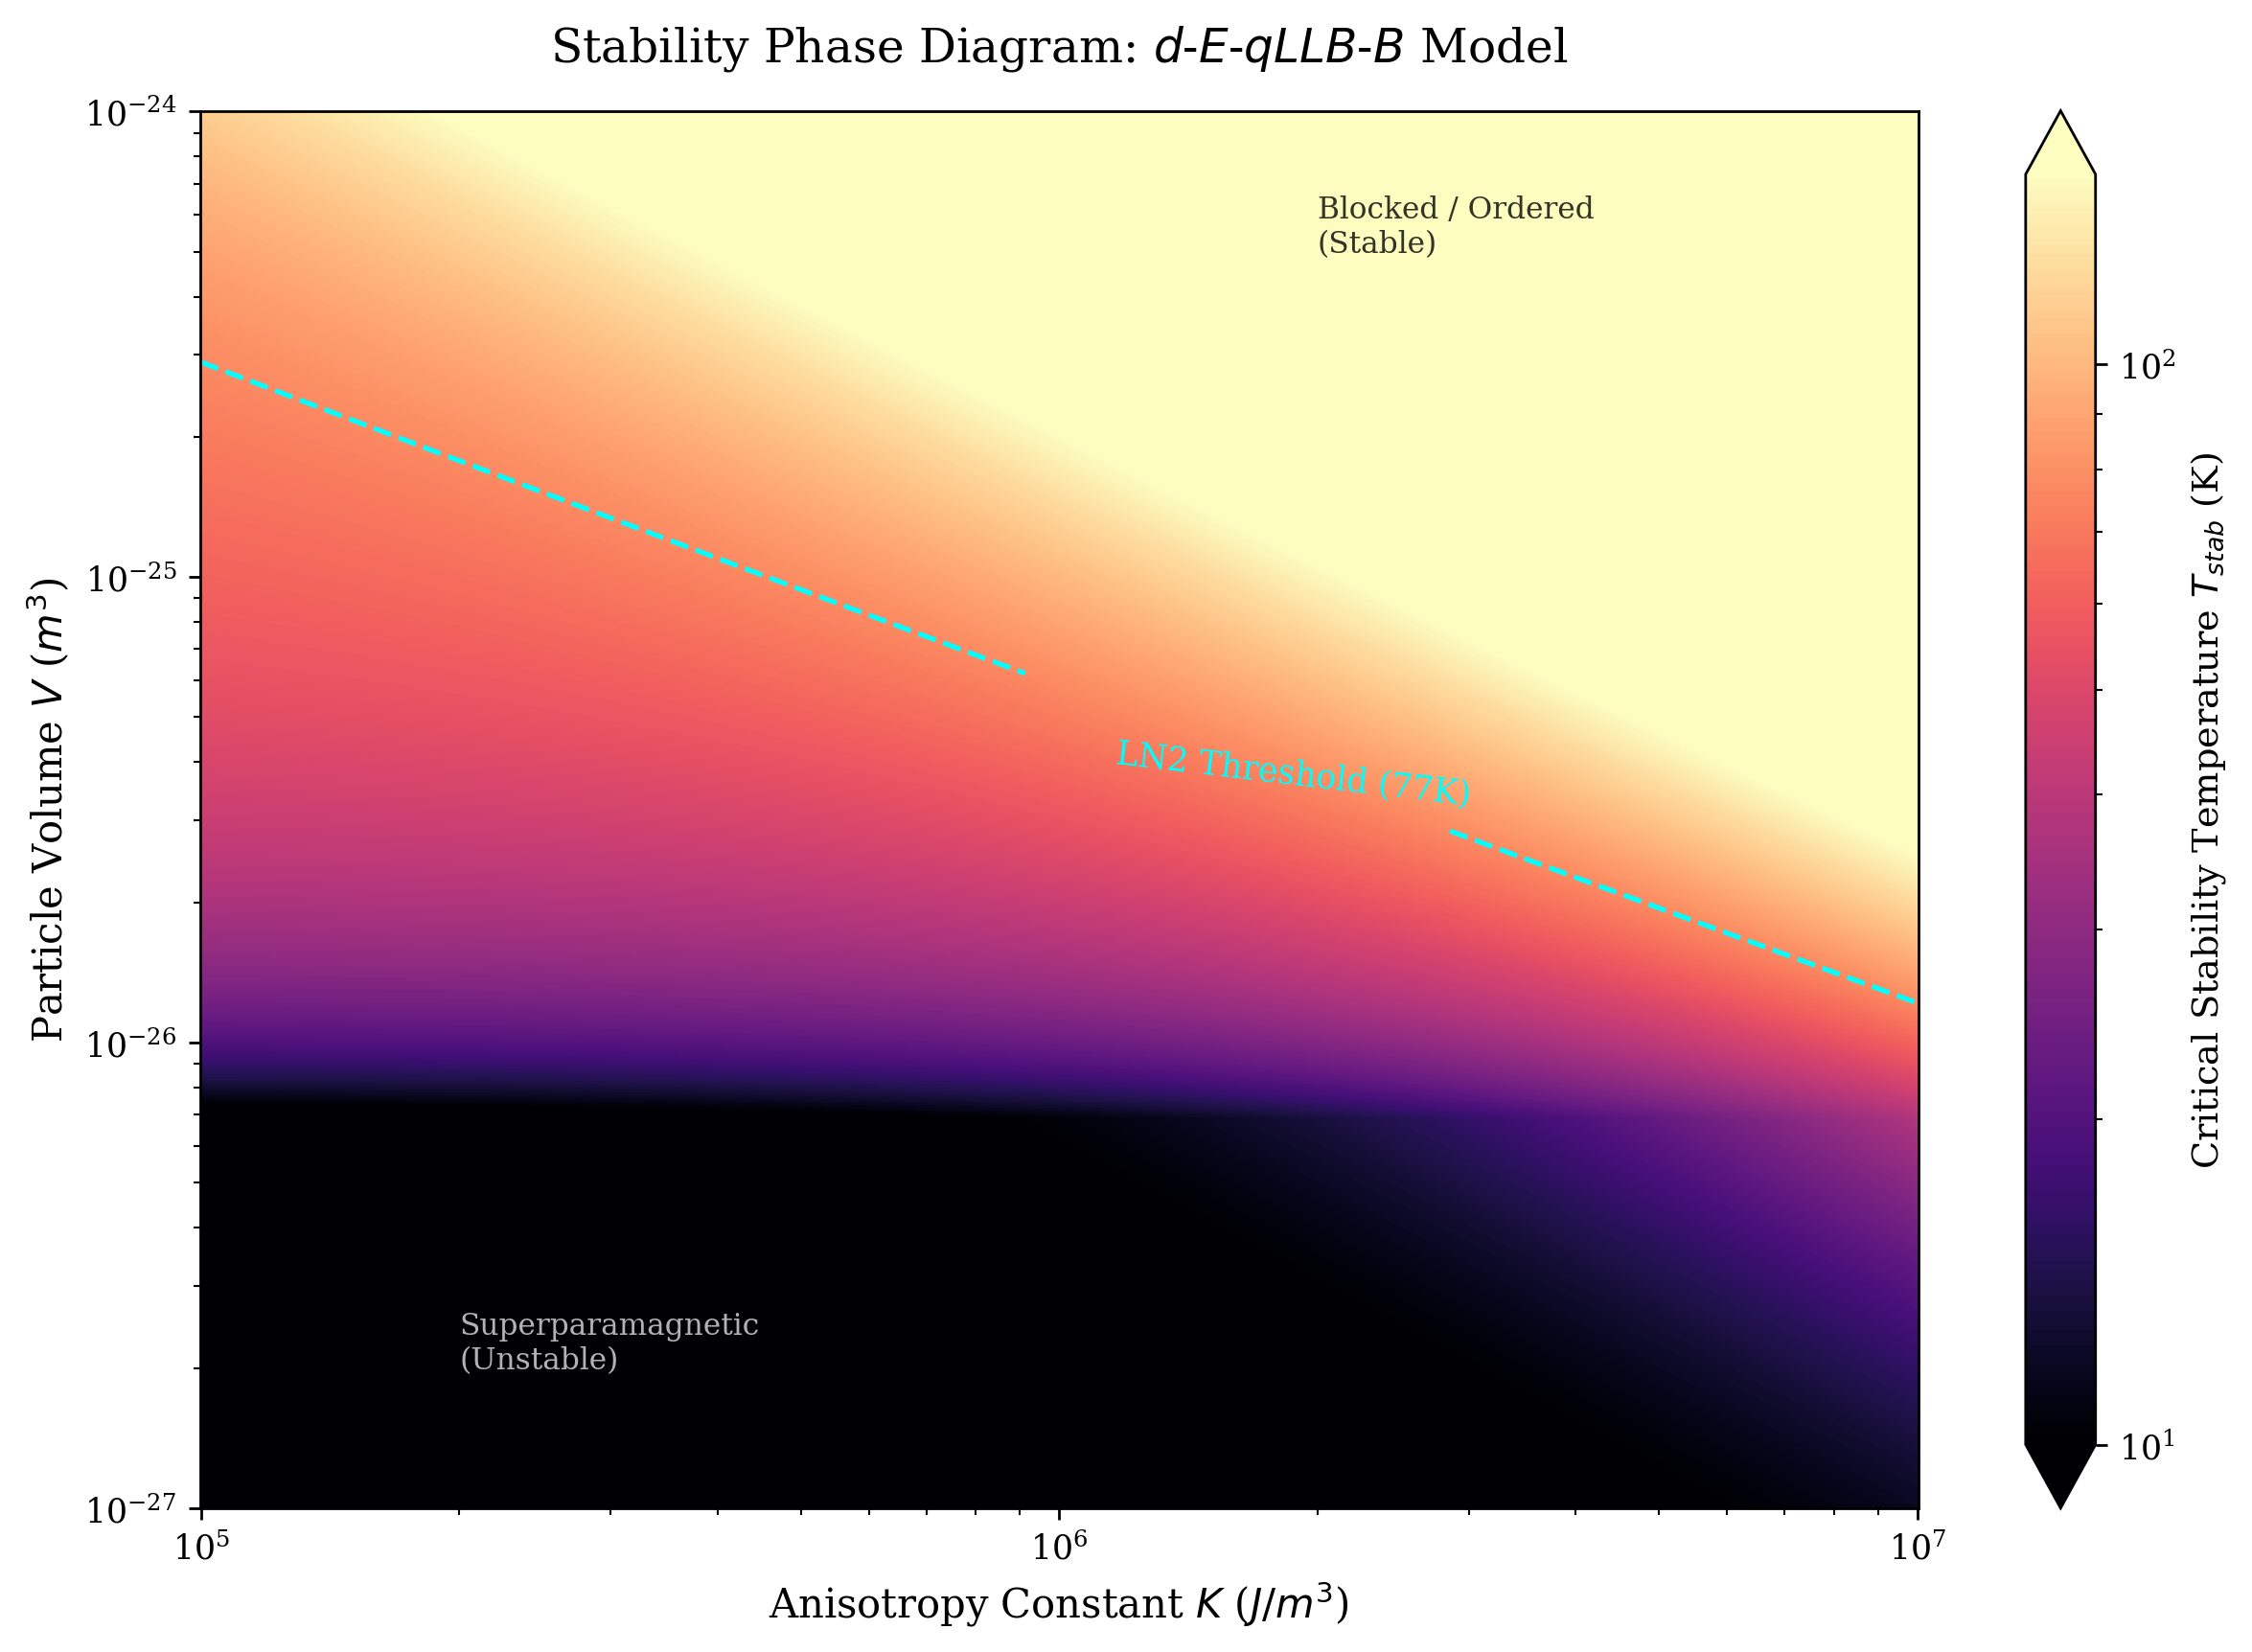

In [ ]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

# --- CONTROL KNOBS ---
DPI_SETTING = 250
K_B = 1.380649e-23          # Boltzmann constant (J/K)
MU_B = 9.27401e-24          # Bohr magneton (J/T)
J_DY = 7.5                  # Dy3+ Total Angular Momentum

# Grid Resolutions (1000x1000 = 10^6 points)
GRID_RES = 1000
K_RANGE = (1e5, 1e7)        # Anisotropy density (J/m^3)
V_RANGE = (1e-27, 1e-24)    # Volume (m^3) - approx 1nm to 10nm clusters

# Physics Knobs
ALPHA_BLEND = 0.85          # Weiss/Ehrenfest weighting
STIFFNESS_CONST = 1.1       # Surface coordination correction
# ---------------------

plt.rcParams['figure.dpi'] = DPI_SETTING
plt.rcParams['font.family'] = 'serif'

def compute_phase_map():
    """Calculates the stability temperature map using CuPy."""
    # Create parameter grids on GPU
    k_vec = cp.logspace(np.log10(K_RANGE[0]), np.log10(K_RANGE[1]), GRID_RES)
    v_vec = cp.logspace(np.log10(V_RANGE[0]), np.log10(V_RANGE[1]), GRID_RES)

    K_grid, V_grid = cp.meshgrid(k_vec, v_vec)

    # Calculate Energy Barrier Delta E = K * V
    delta_e = K_grid * V_grid

    # Effective Tc calculation:
    # We combine the bulk Tc (88K) with the size-scaling factor
    # and the anisotropy-driven stability.
    tc_bulk = 88.0
    radius = ( (3 * V_grid) / (4 * cp.pi) )**(1/3) * 1e9  # Radius in nm

    # Size-scaling factor based on your surface stiffness parameter
    size_scaling = cp.clip(1.0 - (STIFFNESS_CONST / radius)**1.5, 0.1, 1.0)

    # The Stability Temperature (T_stab) is limited by:
    # 1. The inherent exchange (Tc_bulk * scaling)
    # 2. The thermal stability barrier (Delta E / (25 * k_B))
    #    25 is the standard factor for 100s stability.

    t_exchange = tc_bulk * size_scaling
    t_barrier = delta_e / (25 * K_B)

    # Weiss Blend: The Ehrenfest 'kick' preserves order at small scales
    # where pure mean-field theory would predict collapse.
    t_combined = (ALPHA_BLEND * t_exchange) + ((1 - ALPHA_BLEND) * t_barrier)

    # We apply a non-linear saturation to reflect Dy's 4f orbital limits
    t_final = cp.minimum(t_combined, 150.0)

    return cp.asnumpy(k_vec), cp.asnumpy(v_vec), cp.asnumpy(t_final)

def render_phase_diagram(k_vec, v_vec, t_map):
    """Visualizes the K-V stability manifold."""
    fig, ax = plt.subplots(figsize=(10, 7))

    # Use pcolormesh for log-scale grids
    im = ax.pcolormesh(k_vec, v_vec, t_map,
                       shading='auto',
                       cmap='magma',
                       norm=LogNorm(vmin=10, vmax=150))

    # Add contour for the Liquid Nitrogen (77K) threshold
    contours = ax.contour(k_vec, v_vec, t_map, levels=[77.0],
                          colors='cyan', linestyles='--')
    ax.clabel(contours, inline=True, fontsize=10, fmt='LN2 Threshold (77K)')

    # Formatting
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(r"Stability Phase Diagram: $d$-$E$-$qLLB$-$B$ Model", fontsize=14, pad=15)
    ax.set_xlabel(r"Anisotropy Constant $K$ ($J/m^3$)", fontsize=12)
    ax.set_ylabel(r"Particle Volume $V$ ($m^3$)", fontsize=12)

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, extend='both')
    cbar.set_label(r"Critical Stability Temperature $T_{stab}$ (K)", fontsize=11)

    # Annotate regimes
    ax.text(2e5, 2e-27, "Superparamagnetic\n(Unstable)", color='white', alpha=0.7, fontsize=9)
    ax.text(2e6, 5e-25, "Blocked / Ordered\n(Stable)", color='black', alpha=0.8, fontsize=9)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    k, v, t = compute_phase_map()
    render_phase_diagram(k, v, t)